In [2]:
import pandas as pd
import geopandas as gpd


gda_data = pd.read_csv("/Users/twinklesharma511/Downloads/ceew_data/gda_updated_28feb2026.csv")
gda_data.head()

,S No,Compliant ID,Offences,Date and Time,Geo Location,Address,Latitude & Longitude,Department Name,Assigned User Name,Assigned User ID,...,Status,User Feedback,Date & Time of Resolution,Officer Comment,Reopen By Citizen,Reopen By Green Delhi,Resolve Image,Offence Image,Total Action Taken,Month
0,4450.0,103798,Dumping of Construction & Demolition Waste,2026-02-28 17:52:00,"Roshanara Garden, 4744, Roshanara Road, Roshan...","16/3153-3176, Subzi Mandi Railway Colony, Rosh...","28.6704933, 77.1980988",Municipal Corporation of Delhi (MCD),NaN,NaN,...,Pending,NaN,NaN,NaN,NaN,NaN,NaN,https://greendelhi.nic.in/storage/photo/npTEdF...,NaN,Feb 2026
1,4451.0,103797,Potholes on Roads,2026-02-28 16:54:00,"C, 12/544, 12, Atul Marg, Block C, Yamuna Viha...","C-12/1, NEXA Dental & ENT Clinic, opposite to ...","28.6978879, 77.279032",Municipal Corporation of Delhi (MCD),NaN,NaN,...,Pending,NaN,NaN,NaN,NaN,NaN,NaN,https://greendelhi.nic.in/storage/photo/IxmUTi...,NaN,Feb 2026
2,4452.0,103796,Potholes on Roads,2026-02-28 16:53:00,"C485, 5, Atul Marg, Block C, Yamuna Vihar, Sha...","Block C, C490, Block C, Yamuna Vihar, New Delh...","28.6978516, 77.2820386",Municipal Corporation of Delhi (MCD),NaN,NaN,...,Pending,NaN,NaN,NaN,NaN,NaN,NaN,https://greendelhi.nic.in/storage/photo/Yv9Rfb...,NaN,Feb 2026
3,4453.0,103795,Potholes on Roads,2026-02-28 16:52:00,"C12/477, Maujpur Rd, near Office of Executive ...","C485, 5, Atul Marg, Block C, Yamuna Vihar, Sha...","28.6977199, 77.2816192",Municipal Corporation of Delhi (MCD),NaN,NaN,...,Pending,NaN,NaN,NaN,NaN,NaN,NaN,https://greendelhi.nic.in/storage/photo/onXKRS...,NaN,Feb 2026
4,4454.0,103794,Violation of Graded Response Action Plan(GRAP)...,2026-02-28 15:49:00,"1/13, Block 19, West Patel Nagar, Patel Nagar,...","1/13, Block 19, West Patel Nagar, Patel Nagar,...","28.6510258, 77.1693919",Municipal Corporation of Delhi (MCD),NaN,NaN,...,Pending,NaN,NaN,NaN,NaN,NaN,NaN,https://greendelhi.nic.in/storage/photo/6sgXxF...,NaN,Feb 2026


In [3]:
caaqms_data = pd.read_csv("/Users/twinklesharma511/Downloads/ceew_data/caaqms_monitoring_stations - sheet1.csv")
caaqms_data.head()

,location_name_x,lat,lon
0,"Alipur, Delhi - DPCC",28.815329,77.153010
1,"Anand Vihar, New Delhi - DPCC\t",28.646835,77.316032
2,"Ashok Vihar, Delhi - DPCC",28.695381,77.181665
3,"Aya Nagar, New Delhi - IMD",28.474261,77.131606
4,"Bawana, Delhi - DPCC",28.776200,77.051074


In [4]:
shp_data = gpd.read_file("/Users/twinklesharma511/Downloads/ceew_data/Delhi_Wards-SHP_Datameet/Delhi_Wards.shp")
shp_data.head()

,Ward_Name,Ward_No,geometry
0,DELHI CANTT CHARGE 1,CANT_1,"POLYGON ((77.13228 28.63154, 77.13644 28.62062..."
1,DELHI CANTT CHARGE 2,CANT_2,"POLYGON ((77.15429 28.62335, 77.15501 28.62228..."
2,DELHI CANTT CHARGE 4,CANT_4,"POLYGON ((77.15755 28.57578, 77.15672 28.57564..."
3,DELHI CANTT CHARGE 5,CANT_5,"POLYGON ((77.1348 28.57051, 77.13429 28.57048,..."
4,DELHI CANTT CHARGE 6,CANT_6,"POLYGON ((77.12157 28.59308, 77.12878 28.59029..."


In [5]:
# Libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point


# Load GDA data
gda_path = "/Users/twinklesharma511/Downloads/ceew_data/gda_updated_28feb2026.csv"
gda = pd.read_csv(gda_path, encoding="latin1")

# Fix encoding issues
def fix_mojibake(x):
    if isinstance(x, str):
        try:
            return x.encode("latin1").decode("utf-8")
        except:
            return x
    return x

for col in gda.select_dtypes(include='object'):
    gda[col] = gda[col].apply(fix_mojibake)


# Geo processing (GDA)
gda[['Latitude', 'Longitude']] = gda['Latitude & Longitude'].str.split(',', expand=True)

gda['Latitude'] = pd.to_numeric(gda['Latitude'], errors='coerce')
gda['Longitude'] = pd.to_numeric(gda['Longitude'], errors='coerce')

gda = gda.dropna(subset=['Latitude', 'Longitude'])

geometry = [Point(xy) for xy in zip(gda['Longitude'], gda['Latitude'])]
gda_gdf = gpd.GeoDataFrame(gda, geometry=geometry, crs="EPSG:4326")


# Load ward shapefile
shp_path = "/Users/twinklesharma511/Downloads/ceew_data/Delhi_Wards-SHP_Datameet/Delhi_Wards.shp"
delhi_gdf = gpd.read_file(shp_path)

if delhi_gdf.crs != "EPSG:4326":
    delhi_gdf = delhi_gdf.to_crs(epsg=4326)


# Spatial join (complaints → wards)
joined = gpd.sjoin(gda_gdf, delhi_gdf, how='left', predicate='intersects')


# Total complaints
# Total complaints
total_counts = joined.groupby('index_right')['Compliant ID'].nunique()


# Dumping & burning complaints
dumping_burning_offences = [
    'Illegal dumping of Garbage on road sides/ vacant land',
    'Burning of garbage/plastic waste',
    'Burning of Biomass/garden waste'
]

db_data = joined[joined['Offences'].isin(dumping_burning_offences)]
# Dumping & burning complaints
db_counts = db_data.groupby('index_right')['Compliant ID'].nunique()

# Assign to wards
delhi_gdf['total_complaints'] = total_counts.reindex(delhi_gdf.index, fill_value=0)
delhi_gdf['dump_burn_complaints'] = db_counts.reindex(delhi_gdf.index, fill_value=0)


# Final ward table
ward_df = delhi_gdf[['Ward_Name', 'total_complaints', 'dump_burn_complaints']].copy()

ward_df = ward_df.rename(columns={'Ward_Name': "ward_name"})
ward_df["ward_name"] = ward_df["ward_name"].str.strip().str.upper()

final_table = ward_df.copy()


# Top wards (total complaints)
top_total = final_table.sort_values(by="total_complaints", ascending=False).reset_index(drop=True)
top_total_10 = top_total[["ward_name", "total_complaints"]].head(10)


# Top wards (dumping & burning)
top_dump_burn = final_table.sort_values(by="dump_burn_complaints", ascending=False).reset_index(drop=True)
top_dump_burn_10 = top_dump_burn[["ward_name", "dump_burn_complaints"]].head(20)


# Ratio analysis
final_table["dump_burn_ratio"] = (
    final_table["dump_burn_complaints"] / final_table["total_complaints"]
)

top_ratio = final_table.sort_values(by="dump_burn_ratio", ascending=False).reset_index(drop=True)


# Output
print("\nTop 10 Wards - Total Complaints:")
print(top_total_10)

print("\nTop 10 Wards - Dumping & Burning:")
print(top_dump_burn_10)


# Save outputs
top_total_10.to_csv("top_wards_total.csv", index=False)
top_dump_burn_10.to_csv("top_wards_dump_burn.csv", index=False)


Top 10 Wards - Total Complaints:
            ward_name  total_complaints
0             MUNDAKA              2268
1           LADOSARAI              1968
2            KAKRAULA              1696
3               DEOLI              1487
4            MADANGIR              1334
5         POOTH KALAN              1321
6          KISHANGARH              1318
7  KUNWAR SINGH NAGAR              1241
8            BEGUMPUR              1230
9        PUNJABI BAGH              1227

Top 10 Wards - Dumping & Burning:
             ward_name  dump_burn_complaints
0              MUNDAKA                   968
1                DEOLI                   867
2             MADANGIR                   842
3          POOTH KALAN                   651
4            LADOSARAI                   624
5              JHARODA                   624
6                BHATI                   614
7          SONIA VIHAR                   596
8              KHANPUR                   589
9               NARELA                   

In [6]:
# Libraries
import pandas as pd
from IPython.display import display

# LOAD DATA
stations_path = "/Users/twinklesharma511/Downloads/ceew_data/caaqms_station - sheet1.csv"
stations_df = pd.read_csv(stations_path)

# top_total (with ward_name)

# CLEAN FUNCTION
def clean_name(x):
    if pd.isna(x):
        return ""
    x = str(x).upper()
    x = x.replace("DELHI", "")
    x = x.replace("NEW DELHI", "")
    x = x.replace("- DPCC", "")
    x = x.replace("- CPCB", "")
    x = x.replace("- IMD", "")
    x = x.replace(",", "")
    return x.strip()

# APPLY CLEANING
stations_df['clean_name'] = stations_df['location_name'].apply(clean_name)
top_total['clean_ward'] = top_total['ward_name'].apply(clean_name)

# MATCHING
matched_rows = []

for _, ward in top_total.iterrows():
    ward_name = ward['clean_ward']
    
    for _, station in stations_df.iterrows():
        station_name = station['clean_name']
        
        # skip empty values
        if not ward_name or not station_name:
            continue
        
        # flexible match
        if ward_name in station_name or station_name in ward_name:
            matched_rows.append({
                "ward_name": ward['ward_name'],
                "location_name": station['location_name'],
                "lat": station['lat'],
                "lon": station['lon']})

# CREATE DATAFRAME
matched_df = pd.DataFrame(matched_rows)

# REMOVE DUPLICATES
matched_df = matched_df.drop_duplicates(subset=['location_name'])

# OUTPUT
print("\nTotal Matches Found:", len(matched_df))

print("\nMatched Stations with Top Wards:\n")

display(matched_df)   # best for Jupyter

# If not using Jupyter, use:
# print(matched_df.to_string(index=False))


Total Matches Found: 20

Matched Stations with Top Wards:



,ward_name,location_name,lat,lon
0,MUNDAKA,Mundaka,28.684678,77.076574
1,PUNJABI BAGH,Punjabi Bagh,28.674045,77.131023
2,SONIA VIHAR,Sonia Vihar,28.710508,77.249485
3,NARELA,Narela,28.822836,77.101981
4,ALIPUR,Alipur,28.815329,77.153010
5,ANAND VIHAR,Anand Vihar,28.646835,77.316032
6,ROHINI NORTH,Rohini,28.732528,77.119920
7,BAWANA,Bawana,28.776200,77.051074
9,VIVEK VIHAR,Vivek Vihar,28.672342,77.315260
10,BURARI,Burari,28.725650,77.201157


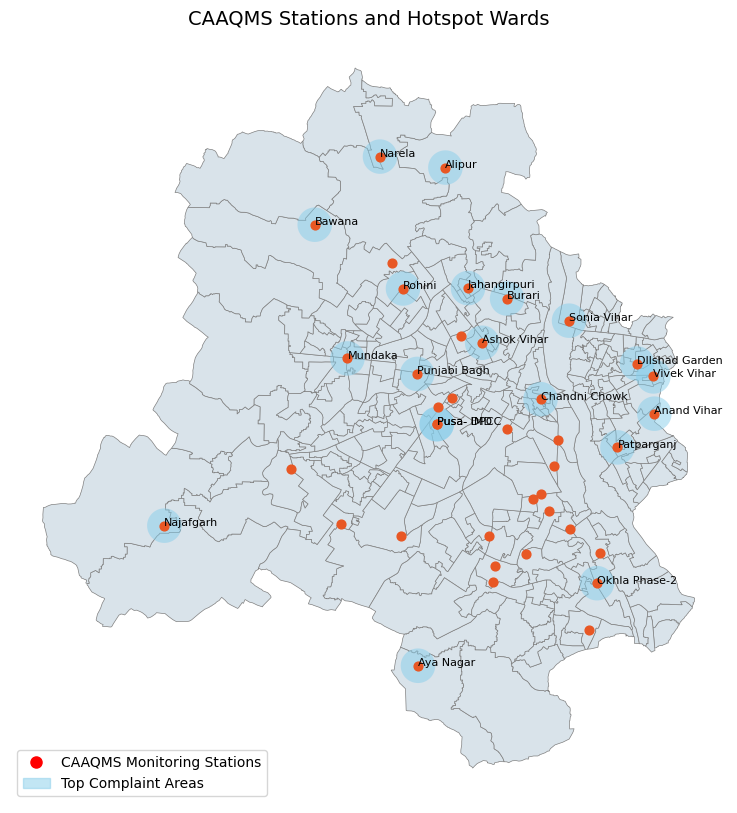

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# LOAD DELHI SHAPEFILE
shp_path = "/Users/twinklesharma511/Downloads/ceew_data/Delhi_Wards-SHP_Datameet/Delhi_Wards.shp"
delhi_gdf = gpd.read_file(shp_path)

if delhi_gdf.crs != "EPSG:4326":
    delhi_gdf = delhi_gdf.to_crs(epsg=4326)

# ALL STATIONS
all_points = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['lon'], stations_df['lat']),
    crs="EPSG:4326")

# MATCHED STATIONS
matched_points = gpd.GeoDataFrame(
    matched_df,
    geometry=gpd.points_from_xy(matched_df['lon'], matched_df['lat']),
    crs="EPSG:4326")

# BUFFER (blue circles)
matched_points_proj = matched_points.to_crs(epsg=3857)
matched_points_proj['geometry'] = matched_points_proj.buffer(1500)
matched_buffer = matched_points_proj.to_crs(epsg=4326)

# PLOT
fig, ax = plt.subplots(figsize=(10, 10))

# wards
delhi_gdf.plot(ax=ax, color="#d9e3ea", edgecolor="grey", linewidth=0.5)

# blue shaded circles (hotspots)
matched_buffer.plot(ax=ax, color="skyblue", alpha=0.5, edgecolor='none')

# red dots (all stations)
all_points.plot(ax=ax, color="#e85724", markersize=40)

# labels for matched stations
for x, y, label in zip(
    matched_points.geometry.x,
    matched_points.geometry.y,
    matched_points['location_name']
):
    ax.text(x, y, label, fontsize=8)

# CUSTOM LEGEND (THIS PART)
red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=8, label='CAAQMS Monitoring Stations')

blue_patch = mpatches.Patch(color='skyblue', alpha=0.5, label= 'Top Complaint Areas')

ax.legend(handles=[red_dot, blue_patch], loc='lower left')

# style
ax.set_title("CAAQMS Stations and Hotspot Wards", fontsize=14)
ax.set_axis_off()

plt.show()

In [8]:
# Libraries
import pandas as pd
from IPython.display import display

# LOAD DATA
stations_path = "/Users/twinklesharma511/Downloads/ceew_data/caaqms_station - sheet1.csv"
stations_df = pd.read_csv(stations_path)

# CLEAN FUNCTION
def clean_name(x):
    if pd.isna(x):
        return ""
    x = str(x).upper()
    x = x.replace("DELHI", "")
    x = x.replace("NEW DELHI", "")
    x = x.replace("- DPCC", "")
    x = x.replace("- CPCB", "")
    x = x.replace("- IMD", "")
    x = x.replace(",", "")
    return x.strip()

# APPLY CLEANING
stations_df['clean_name'] = stations_df['location_name'].apply(clean_name)
top_dump_burn['clean_ward'] = top_dump_burn['ward_name'].apply(clean_name)

# MATCHING
matched_rows = []

for _, ward in top_dump_burn.iterrows():
    ward_name = ward['clean_ward']
    complaints = ward['dump_burn_complaints']
    
    for _, station in stations_df.iterrows():
        station_name = station['clean_name']
        
        if not ward_name or not station_name:
            continue
        
        if ward_name in station_name or station_name in ward_name:
            matched_rows.append({
                "ward_name": ward['ward_name'],
                "dump_burn_complaints": complaints,
                "location_name": station['location_name'],
                "lat": station['lat'],
                "lon": station['lon']
            })

# CREATE DATAFRAME
matched_dump_burn_df = pd.DataFrame(matched_rows)

# AGGREGATE
matched_dump_burn_df = (
    matched_dump_burn_df
    .groupby(['location_name', 'lat', 'lon'], as_index=False)
    .agg({
        'dump_burn_complaints': 'sum',
        'ward_name': lambda x: ', '.join(sorted(set(x)))
    })
)

# ✅ SORT (MOST → LEAST)
matched_dump_burn_df.sort_values(
    by='dump_burn_complaints',
    ascending=False
).reset_index(drop=True)

# OUTPUT
print("\nTotal Stations Matched:", len(matched_dump_burn_df))
print("\nMatched Stations (Sorted by Complaint Count):\n")

display(matched_dump_burn_df)


Total Stations Matched: 20

Matched Stations (Sorted by Complaint Count):



,location_name,lat,lon,dump_burn_complaints,ward_name
0,Alipur,28.815329,77.153010,416,ALIPUR
1,Anand Vihar,28.646835,77.316032,157,ANAND VIHAR
2,Ashok Vihar,28.695381,77.181665,148,ASHOK VIHAR
3,Aya Nagar,28.474261,77.131606,158,AYA NAGAR
4,Bawana,28.776200,77.051074,176,BAWANA
5,Burari,28.725650,77.201157,178,BURARI
6,Chandni Chowk,28.656756,77.227234,113,CHANDNI CHOWK
7,DIlshad Garden,28.681174,77.302523,111,DILSHAD GARDEN
8,Jahangirpuri,28.732820,77.170633,78,JAHANGIRPURI-I
9,Mundaka,28.684678,77.076574,968,MUNDAKA


Map saved at: /Users/twinklesharma511/Downloads/top_caaqms_stations_map.png


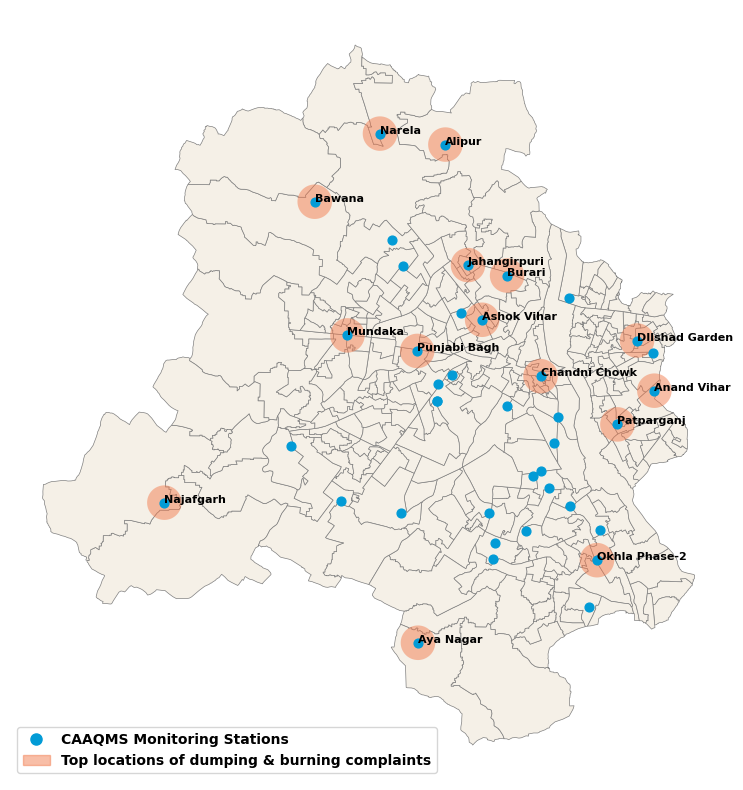

Map saved at: /Users/twinklesharma511/Downloads/top_caaqms_stations_map_1.png


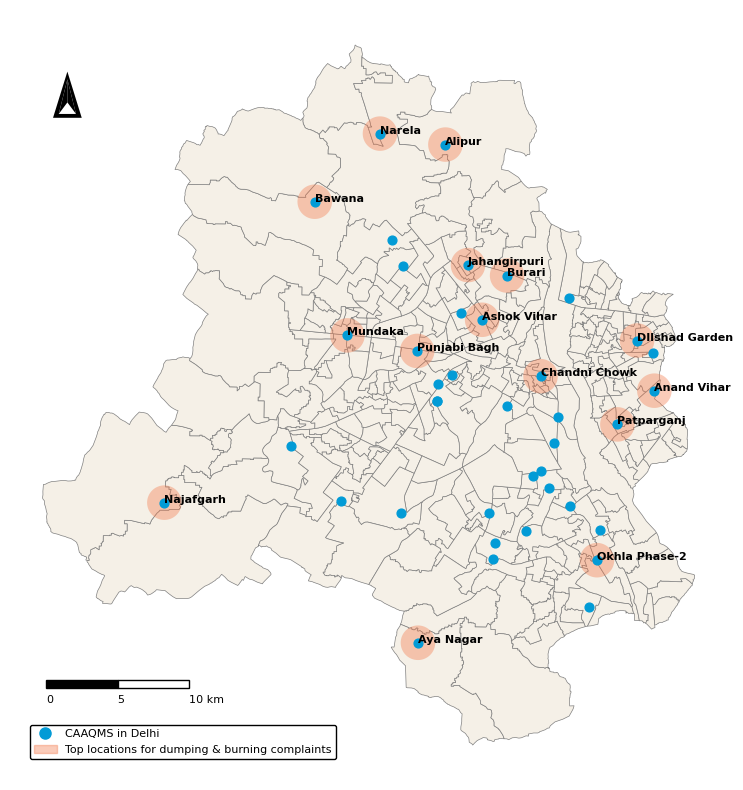

In [33]:
# Libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.patches as patches
from matplotlib.patches import Polygon

# LOAD DELHI SHAPEFILE
shp_path = "/Users/twinklesharma511/Downloads/ceew_data/Delhi_Wards-SHP_Datameet/Delhi_Wards.shp"
delhi_gdf = gpd.read_file(shp_path)

if delhi_gdf.crs != "EPSG:4326":
    delhi_gdf = delhi_gdf.to_crs(epsg=4326)

# ALL 40 STATIONS
all_points = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df['lon'], stations_df['lat']),
    crs="EPSG:4326"
)

# TOP 15 MATCHED
top15_matched = matched_dump_burn_df.head(15)

matched_points = gpd.GeoDataFrame(
    top15_matched,
    geometry=gpd.points_from_xy(top15_matched['lon'], top15_matched['lat']),
    crs="EPSG:4326"
)

# BUFFER (1.5 km)
matched_points_proj = matched_points.to_crs(epsg=3857)
matched_points_proj['geometry'] = matched_points_proj.buffer(1500)
matched_buffer = matched_points_proj.to_crs(epsg=4326)

# PLOT
fig, ax = plt.subplots(figsize=(10, 10))

# wards
delhi_gdf.plot(ax=ax, color="#f5f0e7", edgecolor="grey", linewidth=0.5)

# buffers
matched_buffer.plot(ax=ax, color="#F37E51", alpha=0.4, edgecolor='none')

# stations
all_points.plot(ax=ax, color="#029bd6", markersize=40)

# labels
for x, y, label in zip(
    matched_points.geometry.x,
    matched_points.geometry.y,
    matched_points['location_name']
):
    ax.text(x, y, label, fontsize=8, fontweight='bold')

# ---------------------------
# SCALE BAR (TOP in bottom-left block)
# ---------------------------
x_start, y_start = 0.05, 0.12   # moved UP

bar_width = 0.2

ax.add_patch(patches.Rectangle(
    (x_start, y_start),
    bar_width / 2,
    0.01,
    transform=ax.transAxes,
    color='black'
))

ax.add_patch(patches.Rectangle(
    (x_start + bar_width / 2, y_start),
    bar_width / 2,
    0.01,
    transform=ax.transAxes,
    facecolor='white',
    edgecolor='black'
))

# labels
ax.text(x_start, y_start - 0.02, '0', transform=ax.transAxes, fontsize=8)
ax.text(x_start + bar_width / 2, y_start - 0.02, '5', transform=ax.transAxes, fontsize=8)
ax.text(x_start + bar_width, y_start - 0.02, '10 km', transform=ax.transAxes, fontsize=8)

# ---------------------------
# LEGEND (BELOW scale bar)
# ---------------------------
blue_dot = mlines.Line2D([], [], color='#029bd6', marker='o',
                         linestyle='None', markersize=8,
                         label='CAAQMS in Delhi')

orange_patch = mpatches.Patch(color='#F37E51', alpha=0.4,
                              label='Top locations for dumping & burning complaints')

legend = ax.legend(
    handles=[blue_dot, orange_patch],
    loc='lower left',
    bbox_to_anchor=(0.02, 0.02),  # BELOW scale
    frameon=True,
    fontsize=8
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

# ---------------------------
# NORTH ARROW (unchanged)
# ---------------------------
x, y = 0.08, 0.92

triangle = Polygon([
    (x, y),
    (x - 0.02, y - 0.06),
    (x + 0.02, y - 0.06)
], transform=ax.transAxes, facecolor='black')

inner_triangle = Polygon([
    (x, y - 0.01),
    (x - 0.012, y - 0.055),
    (x + 0.012, y - 0.055)
], transform=ax.transAxes, facecolor='white')

left_split = Polygon([
    (x, y - 0.01),
    (x - 0.012, y - 0.055),
    (x, y - 0.04)
], transform=ax.transAxes, facecolor='black')

right_split = Polygon([
    (x, y - 0.01),
    (x + 0.012, y - 0.055),
    (x, y - 0.04)
], transform=ax.transAxes, facecolor='black')

ax.add_patch(triangle)
ax.add_patch(inner_triangle)
ax.add_patch(left_split)
ax.add_patch(right_split)

# FINAL TOUCHES
ax.set_axis_off()

# SAVE
#output_path = "/Users/twinklesharma511/Downloads/top_caaqms_stations_map_1.png"
#plt.savefig(output_path, dpi=300, bbox_inches='tight')

#print(f"Map saved at: {output_path}")

plt.show()